In [2]:
DATA_PATH = "../data/train.txt"

cols = (["unit_id", "cycle"]
        + [f"op_setting_{i}" for i in range(1, 4)]
        + [f"sensor_{i}" for i in range(1, 22)])

df = pd.read_csv(DATA_PATH, sep=r"\s+", header=None, names=cols)
print(df.shape)
df.head()

(45918, 26)


,unit_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,10.0047,0.2501,20.0,489.05,604.13,1499.45,1309.95,10.52,15.49,394.88,2318.87,8770.20,1.26,45.40,372.15,2388.13,8120.83,8.6216,0.03,368,2319,100.0,28.58,17.1735
1,1,2,0.0015,0.0003,100.0,518.67,642.13,1584.55,1403.96,14.62,21.61,553.67,2388.01,9045.76,1.30,47.29,521.81,2388.15,8132.87,8.3907,0.03,391,2388,100.0,38.99,23.3619
2,1,3,34.9986,0.8401,60.0,449.44,555.42,1368.17,1122.49,5.48,8.00,194.93,2222.86,8343.91,1.02,41.92,183.26,2387.95,8063.84,9.3557,0.02,334,2223,100.0,14.83,8.8555
3,1,4,20.0031,0.7005,0.0,491.19,607.03,1488.44,1249.18,9.35,13.65,334.82,2323.85,8721.53,1.08,44.26,314.84,2388.07,8052.30,9.2231,0.02,364,2324,100.0,24.42,14.7832
4,1,5,42.0041,0.8405,40.0,445.00,549.52,1354.48,1124.32,3.91,5.71,138.24,2211.80,8314.56,1.02,41.79,130.44,2387.89,8083.67,9.2986,0.02,330,2212,100.0,10.99,6.4025


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()
pd.set_option("display.max_columns", 30)

In [4]:
print("machines :", df["unit_id"].nunique())
life = df.groupby("unit_id")["cycle"].max()
print(life.describe())
print("valeurs manquantes :", df.isna().sum().sum())
print("doublons :", df.duplicated().sum())

machines : 218
count    218.000000
mean     210.633028
std       43.595578
min      128.000000
25%      177.000000
50%      209.500000
75%      236.000000
max      357.000000
Name: cycle, dtype: float64
valeurs manquantes : 0
doublons : 0


In [5]:
stats = df.describe().T
stats["std"].sort_values().head(10)

sensor_16       0.004722
sensor_10       0.127832
op_setting_2    0.310935
sensor_15       0.751834
sensor_11       3.243475
sensor_5        3.627125
sensor_19       5.378969
sensor_6        5.451857
sensor_21       5.941954
sensor_20       9.903697
Name: std, dtype: float64

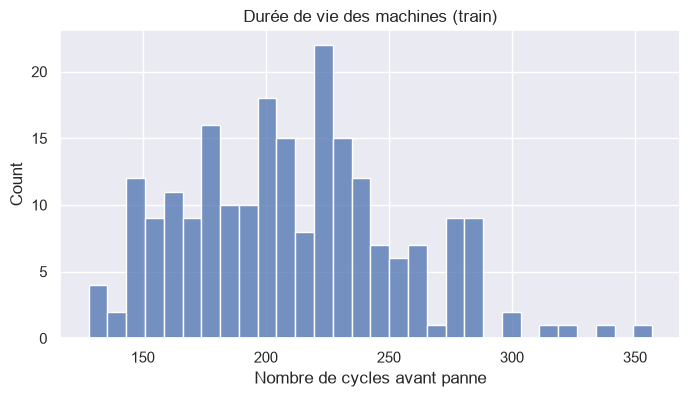

In [6]:
plt.figure(figsize=(8, 4))
sns.histplot(life, bins=30)
plt.xlabel("Nombre de cycles avant panne")
plt.title("Durée de vie des machines (train)")
plt.show()

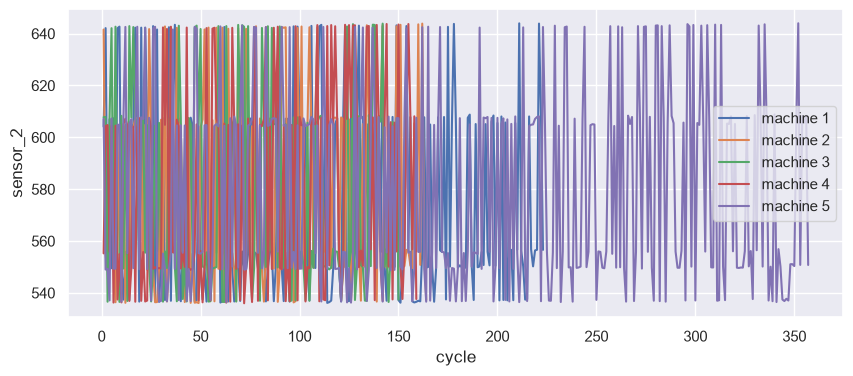

In [7]:
plt.figure(figsize=(10, 4))
for uid in df["unit_id"].unique()[:5]:
    d = df[df["unit_id"] == uid]
    plt.plot(d["cycle"], d["sensor_2"], label=f"machine {uid}")
plt.xlabel("cycle")
plt.ylabel("sensor_2")
plt.legend()
plt.show()

In [8]:
ops = ["op_setting_1", "op_setting_2", "op_setting_3"]
print(df[ops].round(1).drop_duplicates().shape[0], "combinaisons de réglages")
df[ops].round(1).value_counts()

7 combinaisons de réglages


op_setting_1  op_setting_2  op_setting_3
42.0          0.8           40.0            11571
0.0           0.0           100.0            6954
25.0          0.6           80.0             6881
35.0          0.8           60.0             6859
20.0          0.7           0.0              6771
10.0          0.2           20.0             3525
              0.3           20.0             3357
Name: count, dtype: int64

In [9]:
df["regime"] = df.groupby([df[o].round(1) for o in ops]).ngroup()

sensors = [c for c in df.columns if c.startswith("sensor_")]
g = df.groupby("regime")[sensors]
df_norm = df.copy()
df_norm[sensors] = (df[sensors] - g.transform("mean")) / g.transform("std")

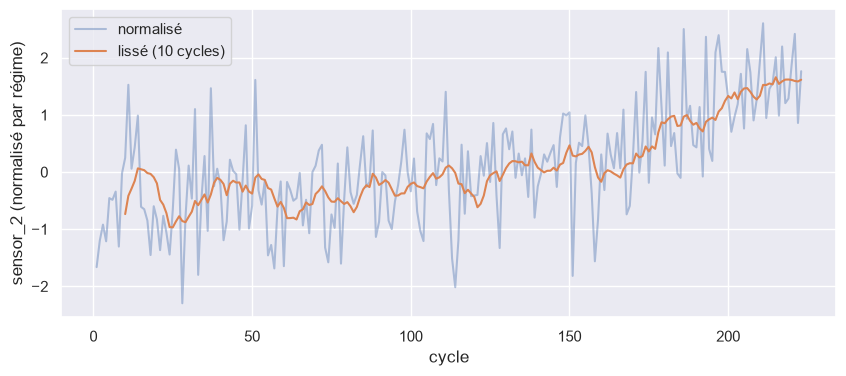

In [10]:
d = df_norm[df_norm["unit_id"] == 1]
plt.figure(figsize=(10, 4))
plt.plot(d["cycle"], d["sensor_2"], alpha=0.4, label="normalisé")
plt.plot(d["cycle"], d["sensor_2"].rolling(10).mean(), label="lissé (10 cycles)")
plt.xlabel("cycle")
plt.ylabel("sensor_2 (normalisé par régime)")
plt.legend()
plt.show()

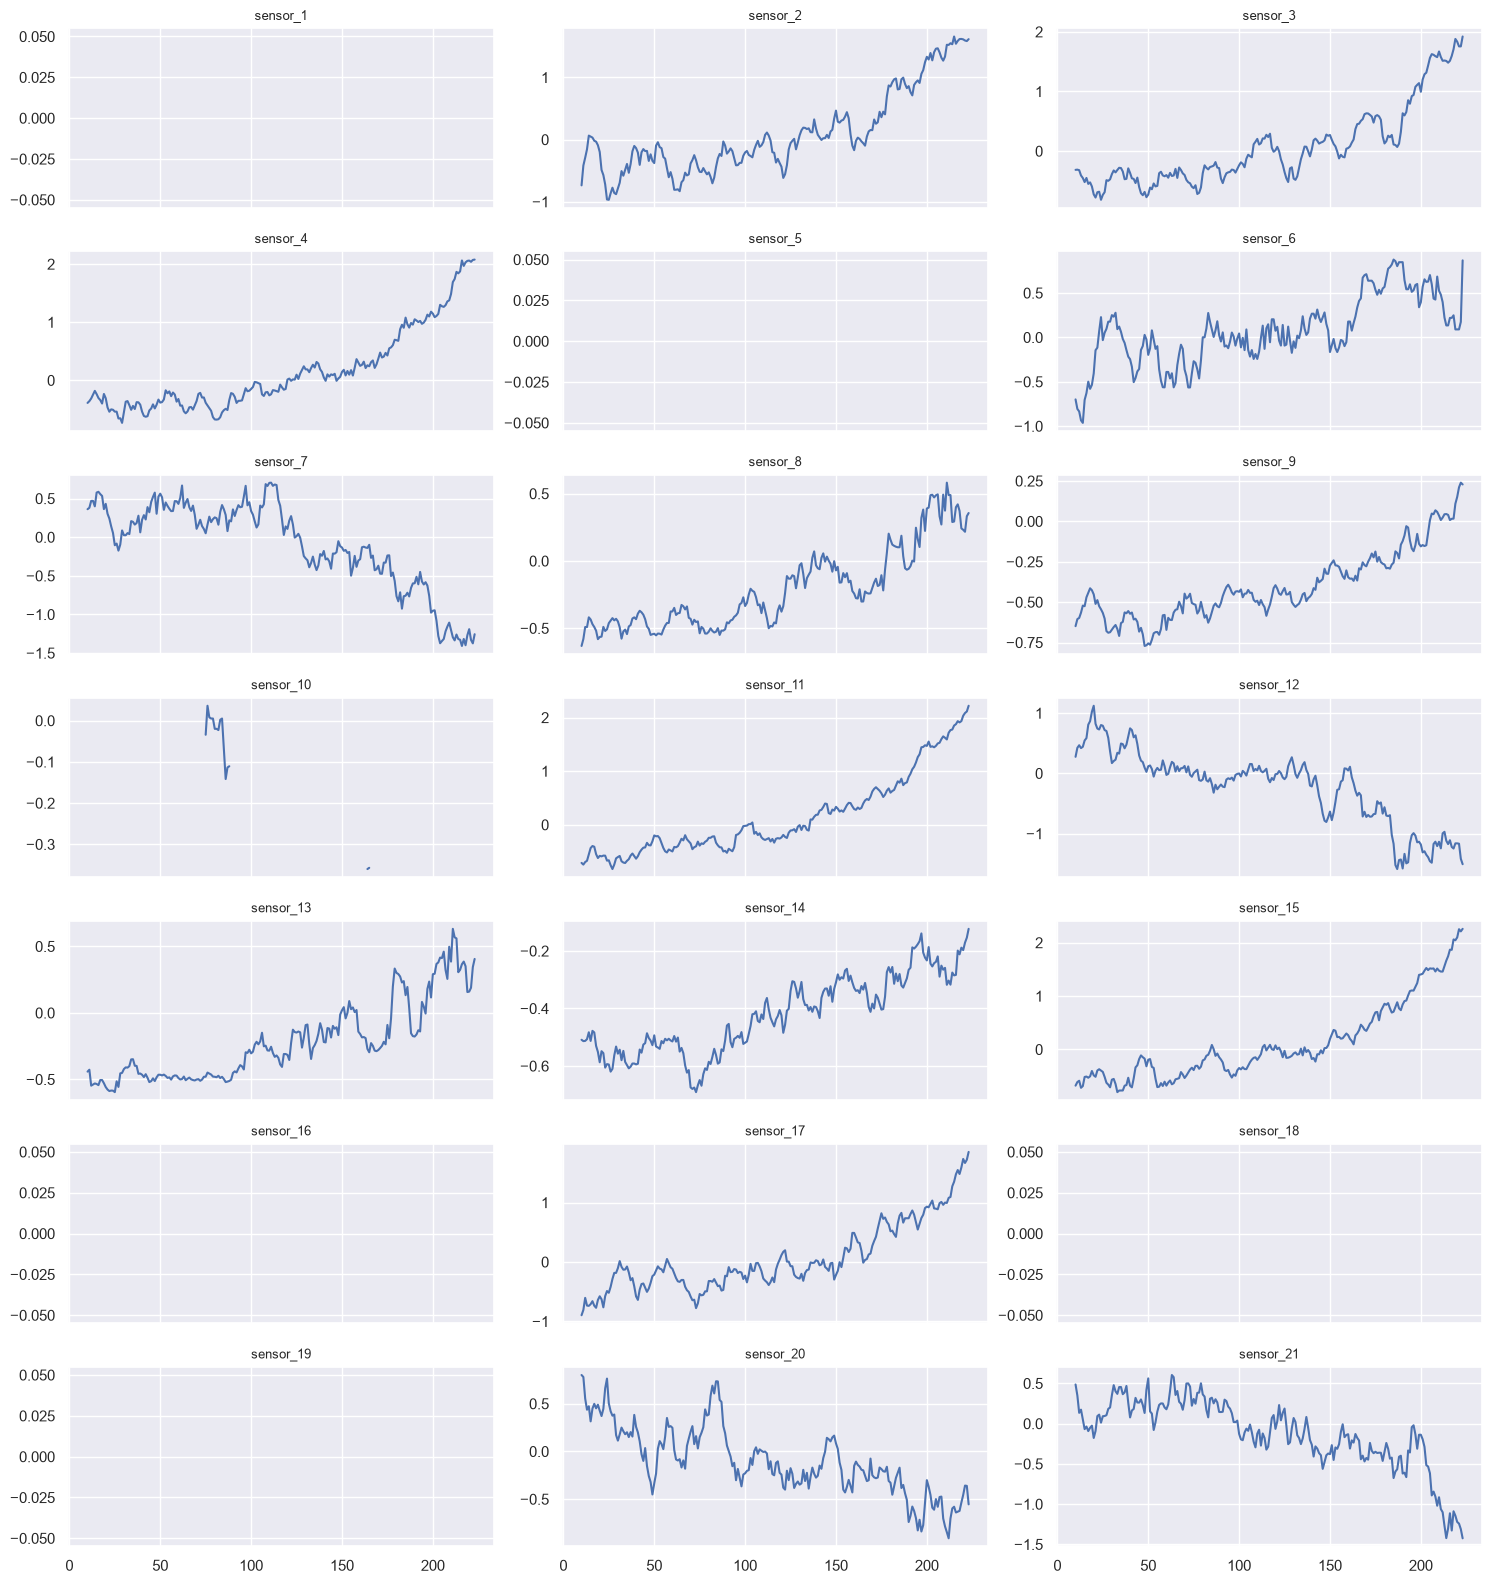

In [11]:
d = df_norm[df_norm["unit_id"] == 1]
fig, axes = plt.subplots(7, 3, figsize=(15, 16), sharex=True)
for ax, s in zip(axes.ravel(), sensors):
    ax.plot(d["cycle"], d[s].rolling(10).mean())
    ax.set_title(s, fontsize=9)
plt.tight_layout()
plt.show()

sensor_11   -0.688382
sensor_4    -0.658506
sensor_15   -0.641790
sensor_17   -0.578954
sensor_16   -0.574121
sensor_2    -0.559234
sensor_3    -0.553256
sensor_13   -0.424752
sensor_8    -0.422231
sensor_9    -0.385804
sensor_6    -0.338391
sensor_14   -0.298169
sensor_10    0.045909
sensor_20    0.422306
sensor_21    0.429519
sensor_7     0.447176
sensor_12    0.473113
Name: RUL, dtype: float64


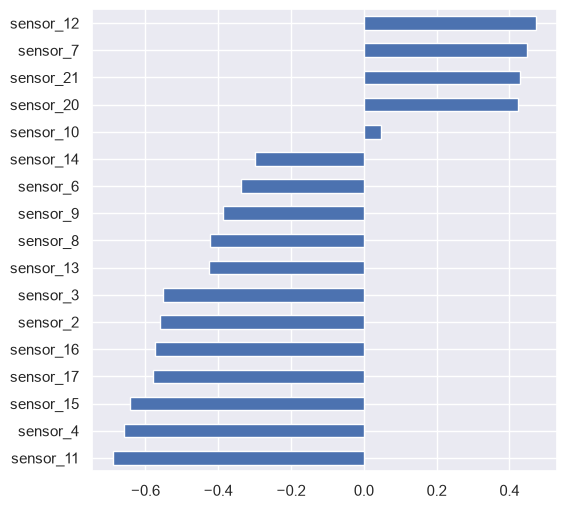

In [12]:
df_norm["RUL"] = df_norm.groupby("unit_id")["cycle"].transform("max") - df_norm["cycle"]
corr = df_norm[sensors + ["RUL"]].corr()["RUL"].drop("RUL").dropna().sort_values()
print(corr)
corr.plot.barh(figsize=(6, 6))
plt.show()

In [13]:
df_norm["RUL_cap"] = df_norm["RUL"].clip(upper=125)
corr_cap = (df_norm[sensors + ["RUL_cap"]].corr()["RUL_cap"]
            .drop("RUL_cap").dropna().sort_values())
print(pd.DataFrame({"RUL": corr, "RUL_cap": corr_cap}).round(2))

            RUL  RUL_cap
sensor_10  0.05     0.04
sensor_11 -0.69    -0.76
sensor_12  0.47     0.52
sensor_13 -0.42    -0.48
sensor_14 -0.30    -0.35
sensor_15 -0.64    -0.71
sensor_16 -0.57    -0.68
sensor_17 -0.58    -0.64
sensor_2  -0.56    -0.62
sensor_20  0.42     0.47
sensor_21  0.43     0.47
sensor_3  -0.55    -0.61
sensor_4  -0.66    -0.73
sensor_6  -0.34    -0.36
sensor_7   0.45     0.50
sensor_8  -0.42    -0.48
sensor_9  -0.39    -0.44


['sensor_11', 'sensor_4', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_2', 'sensor_3', 'sensor_12']


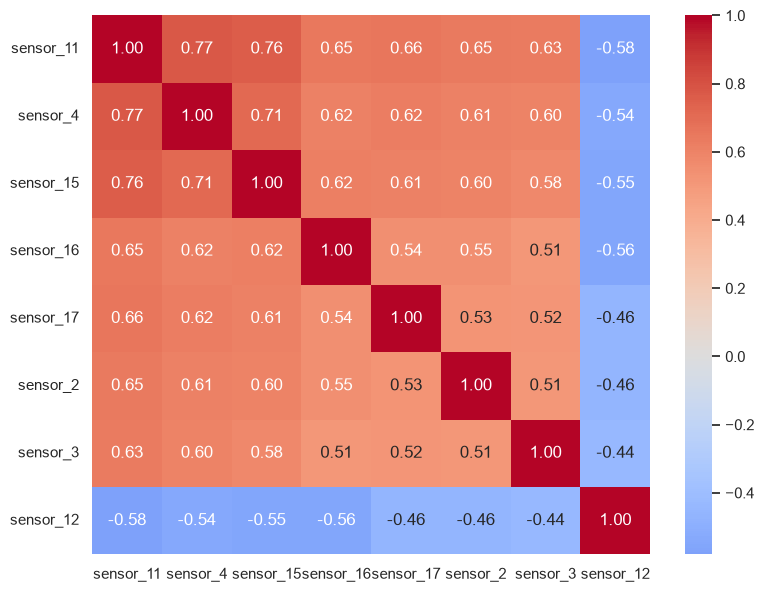

In [14]:
useful = corr_cap[corr_cap.abs() > 0.5].index.tolist()
print(useful)
plt.figure(figsize=(9, 7))
sns.heatmap(df_norm[useful].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.show()

In [18]:
import sys
sys.path.append("..")
from src.data.preprocessing import prepare_train

df_clean, stats = prepare_train("../data/train.txt")
print(df_clean.shape)
df_clean[["unit_id", "cycle", "regime", "sensor_11", "RUL", "RUL_cap"]].head()

ImportError: cannot import name 'prepare_train' from 'src.data.preprocessing' (c:\Users\Lenovo User\Documents\AI-Predictive-Maintenance-Agent\notebooks\..\src\data\preprocessing.py)

In [24]:
import sys
sys.path.append("..")
from src.data.preprocessing import prepare_train

df_clean, stats = prepare_train("../data/train.txt")
print(df_clean.shape)
df_clean[["unit_id", "cycle", "regime", "sensor_11", "RUL", "RUL_cap"]].head()

ImportError: cannot import name 'prepare_train' from 'src.data.preprocessing' (c:\Users\Lenovo User\Documents\AI-Predictive-Maintenance-Agent\notebooks\..\src\data\preprocessing.py)

In [1]:
import sys
sys.path.append("..")
from src.data.preprocessing import prepare_train

df_clean, stats = prepare_train("../data/train.txt")
print(df_clean.shape)
df_clean[["unit_id", "cycle", "regime", "sensor_11", "RUL", "RUL_cap"]].head()

(45918, 29)


c:\Users\Lenovo User\Documents\AI-Predictive-Maintenance-Agent\notebooks\..\src\data\preprocessing.py:38: RuntimeWarning: divide by zero encountered in divide
  df[sensors] = (df[sensors].to_numpy() - m) / s
c:\Users\Lenovo User\Documents\AI-Predictive-Maintenance-Agent\notebooks\..\src\data\preprocessing.py:38: RuntimeWarning: invalid value encountered in divide
  df[sensors] = (df[sensors].to_numpy() - m) / s


,unit_id,cycle,regime,sensor_11,RUL,RUL_cap
0,1,1,10.0|0.3|20.0,-0.375485,222,125
1,1,2,0.0|0.0|100.0,-1.033286,221,125
2,1,3,35.0|0.8|60.0,-0.335412,220,125
3,1,4,20.0|0.7|0.0,-0.877818,219,125
4,1,5,42.0|0.8|40.0,-1.595426,218,125


In [2]:
print(df_clean.shape)
print("régimes :", df_clean["regime"].nunique())
print(df_clean["regime"].value_counts().tail(10))
kept = [c for c in df_clean.columns if c.startswith("sensor_")]
print("NaN :", df_clean[kept].isna().sum().sum())

(45918, 29)
régimes : 7
regime
42.0|0.8|40.0    11571
0.0|0.0|100.0     6954
25.0|0.6|80.0     6881
35.0|0.8|60.0     6859
20.0|0.7|0.0      6771
10.0|0.2|20.0     3525
10.0|0.3|20.0     3357
Name: count, dtype: int64
NaN : 32193
